# 05 · Temporal Drift Experiment

So far, every model has been evaluated using a random train/test split. That works for benchmarking, but it doesn't reflect how fraud systems operate in production.

In reality, models are trained on historical transactions and deployed on future transactions. Fraud patterns evolve over time, so a model that performs well on a random split may struggle when faced with new behaviour.

In this notebook we:

1. Train all models using transactions from months 1–4.
2. Evaluate them on months 5–6, where a new fraud pattern has been introduced.
3. Measure how much performance drops compared with the random-split evaluation.
4. Examine recall on the drifted fraud cases specifically.
5. Retrain the neural network with more recent data and test whether it adapts to the new pattern.

The goal is not to find the model with the highest score, but to understand which models remain reliable when the data distribution changes over time.

In [23]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)
import models as M
import tensorflow as tf

In [24]:
df = pd.read_parquet(os.path.join(ART, '02_features.parquet'))

feature_cols = ([c for c in df.columns if c.startswith('V')] +
                ['amount_log', 'amount_z', 'velocity_10m', 'velocity_1h',
                 'tod_sin', 'tod_cos', 'amount_bucket'])

def prep(train_months, test_months):
    from sklearn.preprocessing import StandardScaler
    tr, te = fu.temporal_split(df, train_months, test_months)
    sc = StandardScaler().fit(tr[feature_cols].values)
    Xtr = sc.transform(tr[feature_cols].values)
    Xte = sc.transform(te[feature_cols].values)
    return tr, te, Xtr, Xte, tr['Class'].values, te['Class'].values

tr, te, Xtr, Xte, ytr, yte = prep([1, 2, 3, 4], [5, 6])
print('train months 1-4:', Xtr.shape, 'fraud', int(ytr.sum()))
print('test  months 5-6:', Xte.shape, 'fraud', int(yte.sum()),
      '| drifted fraud:', int(te['is_drift'].sum()))

train months 1-4: (162522, 35) fraud 356
test  months 5-6: (122285, 35) fraud 136 | drifted fraud: 81


## Train everything on the past, score the future

Same model factories as notebook 03, so any difference is purely the train-on-past / test-on-future regime.

In [25]:
def train_all(Xtr, ytr, Xte):
    out = {}
    sk = M.get_sklearn_models(scale_pos_weight=M.pos_weight(ytr))
    for name, model in sk.items():
        model.fit(Xtr, ytr)
        out[name] = model.predict_proba(Xte)[:, 1]
    net = M.build_keras_mlp(Xtr.shape[1], l2=1e-3, dropout=0.3)
    net.fit(Xtr, ytr, epochs=30, batch_size=512,
            class_weight=M.class_weight_dict(ytr), verbose=0)
    out['nn_reg'] = net.predict(Xte, verbose=0).ravel()
    return out

drift_scores = train_all(Xtr, ytr, Xte)
print('trained:', list(drift_scores))

trained: ['logreg', 'tree', 'random_forest', 'xgboost', 'nn_reg']


## Degradation: random split vs temporal split

We line up each model's AUC-PR from notebook 04 (random, drift leaked into training) against its AUC-PR here (temporal, drift only in the future). The drop is the cost of distribution shift.

In [26]:
random_metrics = pd.read_parquet(os.path.join(ART, '04_metrics.parquet'))

comp = []
for m in drift_scores:
    temporal_ap = fu.evaluate_scores(yte, drift_scores[m])['auc_pr']
    random_ap = random_metrics.loc[m, 'auc_pr'] if m in random_metrics.index else np.nan
    comp.append({'model': m, 'random_split_ap': random_ap,
                 'temporal_ap': temporal_ap,
                 'drop': (random_ap - temporal_ap) if random_ap == random_ap else np.nan})
comp = pd.DataFrame(comp).set_index('model').sort_values('temporal_ap', ascending=False)
comp['%_drop'] = (100 * comp['drop'] / comp['random_split_ap']).round(2)
comp

,random_split_ap,temporal_ap,drop,%_drop
model,,,,
random_forest,0.8285,0.4636,0.3649,44.0400
xgboost,0.8552,0.3843,0.4709,55.0600
logreg,0.6312,0.3182,0.3131,49.6000
nn_reg,0.6831,0.2985,0.3846,56.3100
tree,0.3224,0.0927,0.2297,71.2400


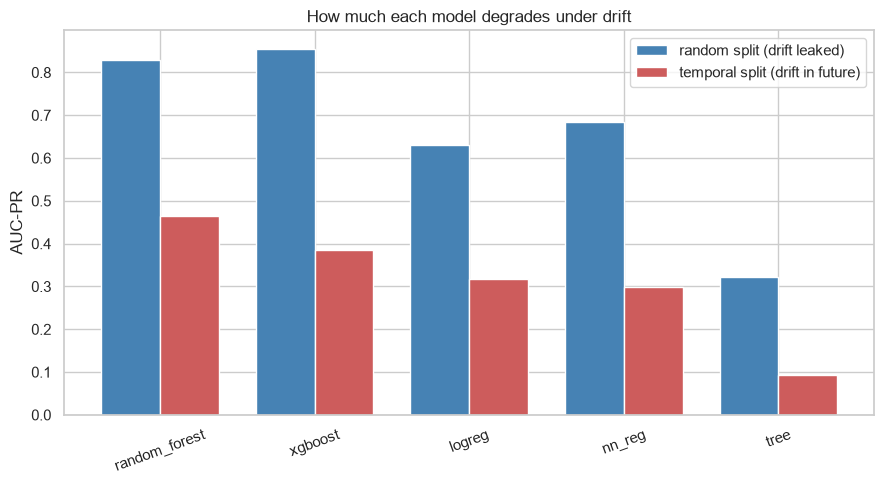

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(comp)); w = 0.38
ax.bar(idx - w/2, comp['random_split_ap'], w, label='random split (drift leaked)',
       color='steelblue')
ax.bar(idx + w/2, comp['temporal_ap'], w, label='temporal split (drift in future)',
       color='indianred')
ax.set_xticks(idx); ax.set_xticklabels(comp.index, rotation=20)
ax.set_ylabel('AUC-PR'); ax.set_title('How much each model degrades under drift')
ax.legend(); plt.tight_layout(); plt.show()

## Where exactly does it fail? Recall on the drifted fraud

Overall AUC-PR hides the mechanism. Split the future fraud into **drifted** (the new pattern) and **normal**, and measure recall on each at a fixed operating threshold. The gap shows the models are blind to the *new* attack while still catching the old one.

In [28]:
thr = 0.5
is_drift_te = te['is_drift'].values
rows = []
for m, s in drift_scores.items():
    pred = (s >= thr).astype(int)
    fraud = yte == 1
    drift_mask = fraud & is_drift_te
    normal_mask = fraud & ~is_drift_te
    rows.append({
        'model': m,
        'recall_normal_fraud': pred[normal_mask].mean() if normal_mask.sum() else np.nan,
        'recall_drifted_fraud': pred[drift_mask].mean() if drift_mask.sum() else np.nan,
    })
recall_tbl = pd.DataFrame(rows).set_index('model')
recall_tbl['gap'] = (
    recall_tbl['recall_normal_fraud']
    - recall_tbl['recall_drifted_fraud']
)

recall_tbl.sort_values(
    'recall_drifted_fraud',
    ascending=False
)

,recall_normal_fraud,recall_drifted_fraud,gap
model,,,
logreg,0.9455,0.2840,0.6615
nn_reg,0.9091,0.1728,0.7363
tree,0.8000,0.0123,0.7877
xgboost,0.8545,0.0123,0.8422
random_forest,0.8364,0.0000,0.8364


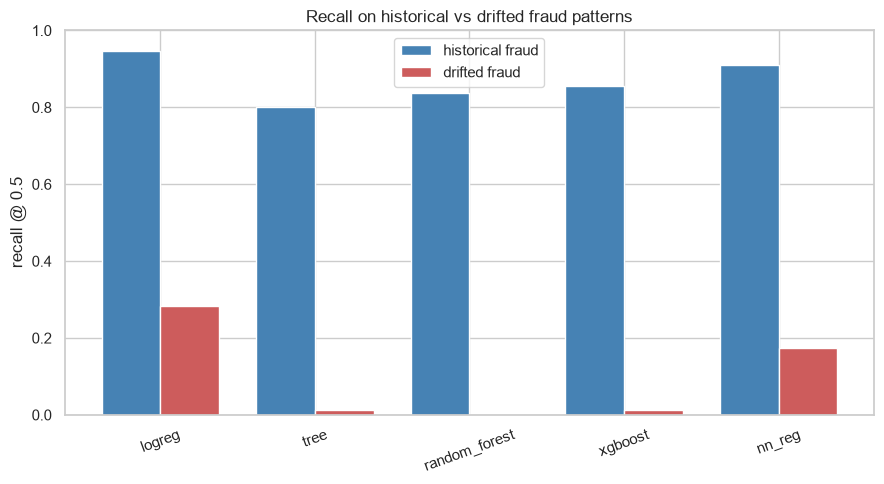

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(recall_tbl)); w = 0.38
ax.bar(idx - w/2, recall_tbl['recall_normal_fraud'], w,
       label='historical fraud', color='steelblue')
ax.bar(idx + w/2, recall_tbl['recall_drifted_fraud'], w,
       label='drifted fraud', color='indianred')
ax.set_xticks(idx); ax.set_xticklabels(recall_tbl.index, rotation=20)
ax.set_ylabel('recall @ 0.5'); ax.set_ylim(0, 1)
ax.set_title('Recall on historical vs drifted fraud patterns')
ax.legend(); plt.tight_layout(); plt.show()

## Recovery: give the neural net one more month

Retraining the neural net on months **1–5** (so it now sees *some* of the new pattern) and testing on month **6**. Comparing its drifted-fraud recall before and after. This is the quantitative version of "just retrain more often."

In [30]:
tr2, te2, Xtr2, Xte2, ytr2, yte2 = prep([1, 2, 3, 4, 5], [6])

net2 = M.build_keras_mlp(Xtr2.shape[1], l2=1e-3, dropout=0.3)
net2.fit(Xtr2, ytr2, epochs=30, batch_size=512,
         class_weight=M.class_weight_dict(ytr2), verbose=0)
s2 = net2.predict(Xte2, verbose=0).ravel()

drift6 = te2['is_drift'].values & (yte2 == 1)
before = None
# 'before' = the month-6 drifted recall from the model trained on 1-4
m6_mask = te['month'].values == 6
prev_pred = (drift_scores['nn_reg'][m6_mask] >= 0.5).astype(int)
prev_drift = drift6_prev = (te[te['month'] == 6]['is_drift'].values &
                            (yte[m6_mask] == 1))
before = prev_pred[prev_drift].mean() if prev_drift.sum() else float('nan')
after = (s2 >= 0.5).astype(int)[drift6].mean() if drift6.sum() else float('nan')
print(f'NN drifted-fraud recall on month 6')
print(f'  trained on months 1-4 (never saw new pattern): {before:.2%}')
print(f'  trained on months 1-5 (saw 1 month of it)    : {after:.2%}')

NN drifted-fraud recall on month 6
  trained on months 1-4 (never saw new pattern): 12.77%
  trained on months 1-5 (saw 1 month of it)    : 87.23%


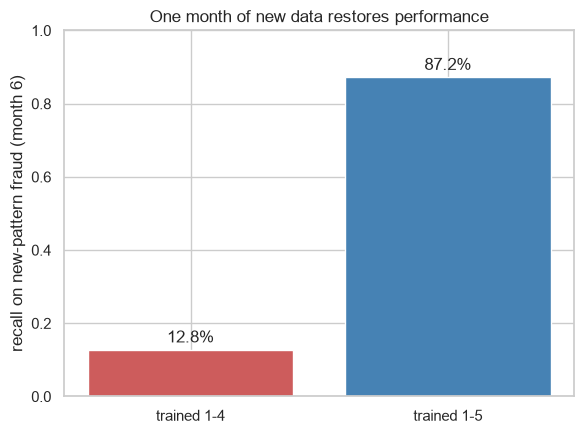

In [31]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['trained 1-4', 'trained 1-5'], [before, after],
       color=['indianred', 'steelblue'])
ax.set_ylim(0, 1); ax.set_ylabel('recall on new-pattern fraud (month 6)')
ax.set_title('One month of new data restores performance')
for i, v in enumerate([before, after]):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.tight_layout(); plt.show()

**Observation:** The retraining experiment was performed only for the neural network to demonstrate recovery after drift. Extending the same procedure to the remaining models would allow a direct comparison of adaptation speed across model families.


After seeing one month of the new fraud pattern, the neural network's recall improved from **12.8%** to **87.2%**, demonstrating rapid recovery through retraining.

## Takeaways

- Random-split evaluation overstated real-world performance.
- All models struggled when the fraud pattern changed.
- The largest drop came from missing the new fraud behaviour, not the old one.
- Retraining with recent data largely restored performance.

The experiment shows that handling drift can matter as much as model selection in a production fraud-detection system.